# Simulation Implementation Notebook (Part-by-Part)

This notebook implements the plan in incremental parts.

## Planned Parts
1. **Part 1 (implemented now):** Data inventory and schema audit for Twitter + OpenAssistant
2. Part 2: Action labeling pipeline (LLM + QA sample)
3. Part 3: Persona feature table + GMM clustering
4. Part 4: RAG index build (turn-level + conversation-level)
5. Part 5: Simulator interface (`reset`, `step`) with state extraction
6. Part 6: Bandit baselines + PPO warm-start scaffold

This run focuses only on **Part 1**.

In [42]:
from pathlib import Path
import csv
import json
import pandas as pd

# Input dataset roots
ROOT = Path(r"B:\\College\\RL\\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service")
TWITTER_ROOT = ROOT / "twitter"
OPENASSIST_ROOT = ROOT / "OpenAssistant Conversations Dataset"

# Output folder for Part 1 artifacts
OUT_DIR = ROOT / "Simulation" / "artifacts" / "part1_data_audit"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TWITTER_ROOT, OPENASSIST_ROOT, OUT_DIR

(WindowsPath('B:/College/RL/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/twitter'),
 WindowsPath('B:/College/RL/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/OpenAssistant Conversations Dataset'),
 WindowsPath('B:/College/RL/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation/artifacts/part1_data_audit'))

In [43]:
def discover_csv_files(*roots):
    files = []
    for root in roots:
        if root.exists():
            files.extend(sorted(root.rglob("*.csv")))
    return files


def count_data_rows(csv_path: Path):
    # Fast line count minus header row; robust fallback if file is empty.
    total_lines = 0
    with csv_path.open("r", encoding="utf-8", errors="ignore") as f:
        for _ in f:
            total_lines += 1
    return max(total_lines - 1, 0)


def read_header(csv_path: Path):
    with csv_path.open("r", encoding="utf-8", errors="ignore", newline="") as f:
        reader = csv.reader(f)
        try:
            return next(reader)
        except StopIteration:
            return []


def sample_missingness(csv_path: Path, sample_rows=50000):
    sample_df = pd.read_csv(csv_path, nrows=sample_rows, low_memory=False)
    miss = (sample_df.isna().mean() * 100).round(2)
    out = pd.DataFrame({
        "column": miss.index,
        "missing_pct_sample": miss.values,
        "sample_rows": len(sample_df)
    })
    return out

In [44]:
csv_files = discover_csv_files(TWITTER_ROOT, OPENASSIST_ROOT)
print(f"Discovered CSV files: {len(csv_files)}")

inventory_rows = []
schema_rows = []

for p in csv_files:
    dataset_group = "twitter" if str(TWITTER_ROOT) in str(p) else "openassistant"
    headers = read_header(p)
    n_rows = count_data_rows(p)
    size_mb = round(p.stat().st_size / (1024 * 1024), 2)

    inventory_rows.append({
        "dataset_group": dataset_group,
        "file_path": str(p),
        "file_name": p.name,
        "size_mb": size_mb,
        "n_rows": n_rows,
        "n_columns": len(headers)
    })

    for col_idx, col in enumerate(headers):
        schema_rows.append({
            "dataset_group": dataset_group,
            "file_name": p.name,
            "column_index": col_idx,
            "column_name": col
        })

inventory_df = pd.DataFrame(inventory_rows).sort_values(["dataset_group", "file_name"])
schema_df = pd.DataFrame(schema_rows).sort_values(["dataset_group", "file_name", "column_index"])

display(inventory_df)
display(schema_df.head(40))

inventory_df.to_csv(OUT_DIR / "part1_file_inventory.csv", index=False)
schema_df.to_csv(OUT_DIR / "part1_schema_columns.csv", index=False)

print("Saved: part1_file_inventory.csv")
print("Saved: part1_schema_columns.csv")

Discovered CSV files: 4


,dataset_group,file_path,file_name,size_mb,n_rows,n_columns
2,openassistant,B:\College\RL\AdaptiveBandit--Contextual-Bandi...,oasst1-train.csv,119.77,771472,18
3,openassistant,B:\College\RL\AdaptiveBandit--Contextual-Bandi...,oasst1-val.csv,6.27,41102,18
0,twitter,B:\College\RL\AdaptiveBandit--Contextual-Bandi...,sample.csv,0.02,99,7
1,twitter,B:\College\RL\AdaptiveBandit--Contextual-Bandi...,twcs.csv,492.58,3003124,7


,dataset_group,file_name,column_index,column_name
14,openassistant,oasst1-train.csv,0,message_id
15,openassistant,oasst1-train.csv,1,parent_id
16,openassistant,oasst1-train.csv,2,user_id
17,openassistant,oasst1-train.csv,3,created_date
18,openassistant,oasst1-train.csv,4,text
19,openassistant,oasst1-train.csv,5,role
20,openassistant,oasst1-train.csv,6,lang
21,openassistant,oasst1-train.csv,7,review_count
22,openassistant,oasst1-train.csv,8,review_result
23,openassistant,oasst1-train.csv,9,deleted


Saved: part1_file_inventory.csv
Saved: part1_schema_columns.csv


In [45]:
missingness_frames = []

for p in csv_files:
    try:
        miss_df = sample_missingness(p, sample_rows=50000)
        miss_df.insert(0, "file_name", p.name)
        miss_df.insert(0, "dataset_group", "twitter" if str(TWITTER_ROOT) in str(p) else "openassistant")
        missingness_frames.append(miss_df)
    except Exception as e:
        missingness_frames.append(pd.DataFrame([{
            "dataset_group": "twitter" if str(TWITTER_ROOT) in str(p) else "openassistant",
            "file_name": p.name,
            "column": "__ERROR__",
            "missing_pct_sample": None,
            "sample_rows": 0,
            "error": str(e)
        }]))

missingness_df = pd.concat(missingness_frames, ignore_index=True)
missingness_df.to_csv(OUT_DIR / "part1_missingness_sample.csv", index=False)

summary = (
    inventory_df.groupby("dataset_group")[["n_rows", "n_columns", "size_mb"]]
    .agg({"n_rows": "sum", "n_columns": "mean", "size_mb": "sum"})
    .rename(columns={"n_rows": "total_rows", "n_columns": "avg_columns_per_file", "size_mb": "total_size_mb"})
    .reset_index()
)
summary.to_csv(OUT_DIR / "part1_dataset_summary.csv", index=False)

report_lines = [
    "# Part 1 Data Audit Report",
    "",
    "## Scope",
    "- Twitter root: " + str(TWITTER_ROOT),
    "- OpenAssistant root: " + str(OPENASSIST_ROOT),
    "",
    "## Outputs",
    "- part1_file_inventory.csv",
    "- part1_schema_columns.csv",
    "- part1_missingness_sample.csv",
    "- part1_dataset_summary.csv",
    "",
    "## Quick Summary",
]

for _, r in summary.iterrows():
    report_lines.append(
        f"- {r['dataset_group']}: rows={int(r['total_rows']):,}, avg_columns_per_file={r['avg_columns_per_file']:.2f}, size_mb={r['total_size_mb']:.2f}"
    )

(OUT_DIR / "part1_data_audit_report.md").write_text("\n".join(report_lines), encoding="utf-8")

display(summary)
display(missingness_df.head(40))
print("Saved: part1_missingness_sample.csv")
print("Saved: part1_dataset_summary.csv")
print("Saved: part1_data_audit_report.md")

,dataset_group,total_rows,avg_columns_per_file,total_size_mb
0,openassistant,812574,18.0,126.04
1,twitter,3003223,7.0,492.60


,dataset_group,file_name,column,missing_pct_sample,sample_rows
0,twitter,sample.csv,tweet_id,0.00,93
1,twitter,sample.csv,author_id,0.00,93
2,twitter,sample.csv,inbound,0.00,93
3,twitter,sample.csv,created_at,0.00,93
4,twitter,sample.csv,text,0.00,93
5,twitter,sample.csv,response_tweet_id,30.11,93
6,twitter,sample.csv,in_response_to_tweet_id,26.88,93
7,twitter,twcs.csv,tweet_id,0.00,50000
8,twitter,twcs.csv,author_id,0.00,50000
9,twitter,twcs.csv,inbound,0.00,50000


Saved: part1_missingness_sample.csv
Saved: part1_dataset_summary.csv
Saved: part1_data_audit_report.md


## Part 1 Complete

Part 1 provides the dataset inventory and schema baseline needed for Part 2 (action labeling).

Next planned implementation:
- Build an action-labeling pipeline that classifies agent turns into the 7-action space.
- Add a small annotation-ready export for inter-rater validation (kappa).

## Part 2: Action Labeling Pipeline (Implemented)

This part builds a practical action-labeling workflow for agent turns.

What this section does:
- Defines the 7-action taxonomy from the implementation plan
- Extracts likely agent turns from available CSV files
- Applies a deterministic heuristic labeler (baseline bootstrap)
- Exports a full labeled dataset and a 200-row annotation set for human validation

Output folder:
- Simulation/artifacts/part2_action_labeling

In [46]:
import re
import numpy as np

PART2_DIR = ROOT / "Simulation" / "artifacts" / "part2_action_labeling"
PART2_DIR.mkdir(parents=True, exist_ok=True)

ACTION_SPACE = [
    "Ask_for_Information",
    "Provide_Solution",
    "Affective_Repair",
    "Escalate_to_Human",
    "Close_with_Feedback",
    "Proactive_Update",
    "Set_Expectation",
]

ACTION_TO_ID = {a: i for i, a in enumerate(ACTION_SPACE)}

ACTION_PATTERNS = {
    "Ask_for_Information": [
        r"\bcan you provide\b", r"\bplease provide\b", r"\bcould you share\b",
        r"\bwhat is your\b", r"\bmay i have\b", r"\border number\b", r"\baccount\b"
    ],
    "Provide_Solution": [
        r"\bplease try\b", r"\byou can\b", r"\bhere is how\b", r"\bsteps?\b",
        r"\bresolved\b", r"\bfix\b", r"\bsolution\b", r"\bupdate your app\b"
    ],
    "Affective_Repair": [
        r"\bsorry\b", r"\bapolog\w*\b", r"\bunderstand how\b", r"\bfrustrat\w*\b",
        r"\bwe understand\b", r"\bthanks for your patience\b"
    ],
    "Escalate_to_Human": [
        r"\bescalat\w*\b", r"\bsupervisor\b", r"\bspecialist\b", r"\bhuman agent\b",
        r"\bforward this to\b", r"\bcontact support team\b"
    ],
    "Close_with_Feedback": [
        r"\banything else\b", r"\bhappy to help\b", r"\bglad to help\b",
        r"\brate your experience\b", r"\bthank you\b", r"\bhave a great day\b"
    ],
    "Proactive_Update": [
        r"\bquick update\b", r"\bstatus update\b", r"\bwe are still working\b",
        r"\bkeeping you posted\b", r"\bno action needed yet\b"
    ],
    "Set_Expectation": [
        r"\bwithin \d+\s?(minutes?|hours?|days?)\b", r"\bby end of day\b", r"\bexpect\b",
        r"\bnext steps\b", r"\btimeline\b", r"\bETA\b"
    ],
}


def clean_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def heuristic_action_label(text):
    t = clean_text(text).lower()
    if not t:
        return "Provide_Solution", 0.2, "empty_or_missing_text_default"

    scores = {a: 0 for a in ACTION_SPACE}
    reasons = []

    for action, pats in ACTION_PATTERNS.items():
        for pat in pats:
            if re.search(pat, t):
                scores[action] += 1
                reasons.append(f"{action}:{pat}")

    tie_order = [
        "Escalate_to_Human",
        "Affective_Repair",
        "Ask_for_Information",
        "Set_Expectation",
        "Proactive_Update",
        "Provide_Solution",
        "Close_with_Feedback",
    ]

    best_score = max(scores.values())
    if best_score == 0:
        label = "Provide_Solution"
        confidence = 0.35
        reason = "no_pattern_match_default"
    else:
        top = [a for a, s in scores.items() if s == best_score]
        label = sorted(top, key=lambda x: tie_order.index(x))[0]
        confidence = min(0.5 + 0.12 * best_score, 0.95)
        reason = ";".join(reasons[:5])

    return label, confidence, reason

In [47]:
def extract_agent_turns_from_csv(path, max_rows=300000, chunk_size=100000):
    records = []
    source_name = path.name
    is_twitter = "twitter" in str(path).lower() or "twcs" in source_name.lower()

    try:
        for chunk in pd.read_csv(path, chunksize=chunk_size, low_memory=False):
            if len(records) >= max_rows:
                break

            cols = set(chunk.columns)

            if {"inbound", "text"}.issubset(cols):
                sub = chunk[chunk["inbound"].astype(str).str.lower().isin(["false", "0"])].copy()
                if sub.empty:
                    continue
                keep_cols = [c for c in ["tweet_id", "author_id", "created_at", "text", "in_response_to_tweet_id", "response_tweet_id"] if c in sub.columns]
                sub = sub[keep_cols].copy()
                sub["source_file"] = source_name
                sub["dataset_group"] = "twitter" if is_twitter else "openassistant"
                sub["speaker_proxy"] = "agent"
                sub = sub.rename(columns={"text": "agent_text"})
                records.extend(sub.to_dict("records"))
                continue

            role_col = None
            for c in ["role", "speaker", "from", "author_role"]:
                if c in cols:
                    role_col = c
                    break

            text_col = None
            for c in ["text", "message", "utterance", "content"]:
                if c in cols:
                    text_col = c
                    break

            if role_col and text_col:
                mask = chunk[role_col].astype(str).str.lower().isin(["assistant", "agent", "support", "system"])
                sub = chunk.loc[mask, [role_col, text_col]].copy()
                if sub.empty:
                    continue
                sub["source_file"] = source_name
                sub["dataset_group"] = "openassistant" if "openassistant" in str(path).lower() else "twitter"
                sub["speaker_proxy"] = "agent"
                sub = sub.rename(columns={text_col: "agent_text"})
                records.extend(sub.to_dict("records"))

            if len(records) >= max_rows:
                break

    except Exception as e:
        print(f"Skipping {source_name} due to read error: {e}")

    if not records:
        return pd.DataFrame(columns=["source_file", "dataset_group", "speaker_proxy", "agent_text"])

    out = pd.DataFrame(records).head(max_rows)
    out["agent_text"] = out["agent_text"].map(clean_text)
    out = out[out["agent_text"].str.len() > 0].copy()
    return out


agent_turns_frames = []
for p in csv_files:
    extracted = extract_agent_turns_from_csv(p, max_rows=200000 if "twcs" in p.name.lower() else 50000)
    if not extracted.empty:
        agent_turns_frames.append(extracted)

if not agent_turns_frames:
    raise RuntimeError("No agent-turn candidates found. Check source schema assumptions.")

agent_turns_df = pd.concat(agent_turns_frames, ignore_index=True)
agent_turns_df = agent_turns_df.drop_duplicates(subset=["source_file", "agent_text"]).reset_index(drop=True)

labels = agent_turns_df["agent_text"].map(heuristic_action_label)
agent_turns_df["action_label"] = labels.map(lambda x: x[0])
agent_turns_df["action_id"] = agent_turns_df["action_label"].map(ACTION_TO_ID)
agent_turns_df["action_confidence"] = labels.map(lambda x: x[1])
agent_turns_df["label_reason"] = labels.map(lambda x: x[2])

print(f"Agent turns labeled: {len(agent_turns_df):,}")
agent_turns_df[["source_file", "dataset_group", "agent_text", "action_label", "action_confidence"]].head(10)

Agent turns labeled: 251,908


,source_file,dataset_group,agent_text,action_label,action_confidence
0,sample.csv,twitter,@105835 Your business means a lot to us. Pleas...,Provide_Solution,0.35
1,sample.csv,twitter,@105836 LiveChat is online at the moment - htt...,Provide_Solution,0.35
2,sample.csv,twitter,"@105836 Have you tried from another device, Mi...",Provide_Solution,0.35
3,sample.csv,twitter,"@105836 It's working OK from here, Miriam. Doe...",Provide_Solution,0.35
4,sample.csv,twitter,@105836 That's what we're here for Miriam 😊 T...,Provide_Solution,0.35
5,sample.csv,twitter,@105837 We can help. Which version of iOS are ...,Provide_Solution,0.62
6,sample.csv,twitter,@105839 Thanks for reaching out to us. We are ...,Close_with_Feedback,0.62
7,sample.csv,twitter,@105840 Hi there! What device is this happenin...,Provide_Solution,0.35
8,sample.csv,twitter,@105840 Thanks. The distance could possibly af...,Provide_Solution,0.35
9,sample.csv,twitter,@105840 That's great to hear. If anything come...,Provide_Solution,0.35


In [48]:
full_labeled_path = PART2_DIR / "part2_agent_turns_labeled.csv"
agent_turns_df.to_csv(full_labeled_path, index=False)

np.random.seed(42)
per_class = max(1, 200 // len(ACTION_SPACE))
annotation_parts = []

for action in ACTION_SPACE:
    pool = agent_turns_df[agent_turns_df["action_label"] == action]
    if pool.empty:
        continue
    take = min(per_class, len(pool))
    annotation_parts.append(pool.sample(n=take, random_state=42))

annotation_df = pd.concat(annotation_parts, ignore_index=True)

if len(annotation_df) < 200:
    extra_needed = 200 - len(annotation_df)
    used_ids = set(annotation_df.index.tolist())
    remaining = agent_turns_df.loc[~agent_turns_df.index.isin(used_ids)]
    if len(remaining) > 0:
        annotation_df = pd.concat(
            [annotation_df, remaining.sample(n=min(extra_needed, len(remaining)), random_state=42)],
            ignore_index=True,
        )

annotation_df = annotation_df.head(200).copy()
annotation_df.insert(0, "annotation_id", [f"ann_{i:04d}" for i in range(1, len(annotation_df) + 1)])
annotation_df["human_label"] = ""
annotation_df["human_notes"] = ""

annotation_export_cols = [
    "annotation_id",
    "source_file",
    "dataset_group",
    "agent_text",
    "action_label",
    "action_id",
    "action_confidence",
    "label_reason",
    "human_label",
    "human_notes",
]

annotation_path = PART2_DIR / "part2_annotation_sample_200.csv"
annotation_df[annotation_export_cols].to_csv(annotation_path, index=False)

label_dist = agent_turns_df["action_label"].value_counts().rename_axis("action_label").reset_index(name="count")
label_dist["pct"] = (label_dist["count"] / label_dist["count"].sum() * 100).round(2)
label_dist_path = PART2_DIR / "part2_label_distribution.csv"
label_dist.to_csv(label_dist_path, index=False)

prompt_template = {
    "system": "You are an expert customer support analyst.",
    "instruction": "Classify the agent utterance into exactly one of the 7 actions.",
    "actions": ACTION_SPACE,
    "output_format": {
        "action_label": "string",
        "confidence": "0.0-1.0",
        "reasoning": "short rationale"
    }
}

with (PART2_DIR / "part2_llm_label_prompt_template.json").open("w", encoding="utf-8") as f:
    json.dump(prompt_template, f, indent=2)

summary_rows = [
    {"metric": "total_labeled_turns", "value": int(len(agent_turns_df))},
    {"metric": "annotation_sample_size", "value": int(len(annotation_df))},
    {"metric": "num_action_classes_present", "value": int(agent_turns_df["action_label"].nunique())}
]

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(PART2_DIR / "part2_summary_metrics.csv", index=False)

display(label_dist)
print("Saved:", full_labeled_path)
print("Saved:", annotation_path)
print("Saved:", label_dist_path)
print("Saved:", PART2_DIR / "part2_summary_metrics.csv")
print("Saved:", PART2_DIR / "part2_llm_label_prompt_template.json")

,action_label,count,pct
0,Provide_Solution,188101,74.67
1,Affective_Repair,39209,15.56
2,Close_with_Feedback,11401,4.53
3,Ask_for_Information,11073,4.40
4,Escalate_to_Human,1321,0.52
5,Set_Expectation,785,0.31
6,Proactive_Update,18,0.01


Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part2_action_labeling\part2_agent_turns_labeled.csv
Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part2_action_labeling\part2_annotation_sample_200.csv
Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part2_action_labeling\part2_label_distribution.csv
Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part2_action_labeling\part2_summary_metrics.csv
Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part2_action_labeling\part2_llm_label_prompt_template.json


## Part 3: Persona Feature Engineering + GMM Clustering (Implemented)

This part creates conversation-level persona features and clusters them with Gaussian Mixture Models.

What this section does:
- Builds user/conversation proxy features from Twitter customer turns
- Computes behavior-oriented persona features (sentiment baseline, volatility, escalation tendency, dropout, etc.)
- Selects number of clusters via BIC
- Assigns soft and hard persona labels
- Exports clustering artifacts and summary files

Output folder:
- Simulation/artifacts/part3_persona_clustering

In [49]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

PART3_DIR = ROOT / "Simulation" / "artifacts" / "part3_persona_clustering"
PART3_DIR.mkdir(parents=True, exist_ok=True)

ESCALATION_PATTERNS = [
    r"\bmanager\b", r"\bsupervisor\b", r"\bescalat\w*\b", r"\bcomplaint\b",
    r"\blegal\b", r"\bunacceptable\b", r"\bangry\b", r"\bfrustrat\w*\b"
]
POS_WORDS = {"thanks", "thank", "great", "happy", "appreciate", "good", "helpful", "resolved", "awesome"}
NEG_WORDS = {"bad", "worst", "terrible", "angry", "upset", "frustrated", "hate", "useless", "awful", "ridiculous"}


def heuristic_sentiment(text):
    t = clean_text(text).lower()
    if not t:
        return 0.0
    tokens = re.findall(r"[a-z']+", t)
    if not tokens:
        return 0.0
    pos = sum(tok in POS_WORDS for tok in tokens)
    neg = sum(tok in NEG_WORDS for tok in tokens)
    raw = (pos - neg) / max(len(tokens), 1)
    return float(np.tanh(5 * raw))


def frustration_proxy(text):
    t = clean_text(text)
    if not t:
        return 0.0
    upper_ratio = sum(ch.isupper() for ch in t) / max(sum(ch.isalpha() for ch in t), 1)
    excl = t.count("!")
    has_escalation_kw = any(re.search(p, t.lower()) for p in ESCALATION_PATTERNS)
    score = 0.45 * min(upper_ratio * 3, 1.0) + 0.25 * min(excl / 3, 1.0) + 0.30 * float(has_escalation_kw)
    return float(min(max(score, 0.0), 1.0))


def classify_persona_name(row):
    if row["dropout_flag"] >= 1 and row["avg_utterance_length"] < 12:
        return "silent_dropout"
    if row["escalation_event_rate"] >= 0.20 or row["first_turn_frustration"] >= 0.55:
        return "escalation_prone"
    if row["sentiment_volatility"] >= 0.45 and row["avg_utterance_length"] < 20:
        return "impatient"
    return "cooperative"

In [50]:
# Load Twitter conversation data for persona modeling
# We prioritize twcs.csv, then fallback to sample.csv if needed.

twitter_candidates = [
    TWITTER_ROOT / "twcs" / "twcs.csv",
    TWITTER_ROOT / "sample.csv",
]

source_twitter_path = None
for c in twitter_candidates:
    if c.exists():
        source_twitter_path = c
        break

if source_twitter_path is None:
    raise FileNotFoundError("No Twitter CSV found for Part 3. Expected twcs/twcs.csv or sample.csv.")

MAX_ROWS_PART3 = 400000
raw_df = pd.read_csv(source_twitter_path, nrows=MAX_ROWS_PART3, low_memory=False)

required_cols = ["author_id", "text", "inbound"]
missing_cols = [c for c in required_cols if c not in raw_df.columns]
if missing_cols:
    raise ValueError(f"Part 3 requires columns {required_cols}. Missing: {missing_cols}")

# Keep customer turns only (inbound True/1)
inbound_mask = raw_df["inbound"].astype(str).str.lower().isin(["true", "1"])
user_df = raw_df.loc[inbound_mask].copy()

# Timestamp handling
if "created_at" in user_df.columns:
    user_df["created_at_dt"] = pd.to_datetime(user_df["created_at"], errors="coerce", utc=True)
else:
    user_df["created_at_dt"] = pd.NaT

user_df["text"] = user_df["text"].map(clean_text)
user_df = user_df[user_df["text"].str.len() > 0].copy()

# Feature primitives
user_df["sentiment_score"] = user_df["text"].map(heuristic_sentiment)
user_df["frustration_proxy"] = user_df["text"].map(frustration_proxy)
user_df["escalation_flag"] = user_df["text"].str.lower().apply(lambda t: int(any(re.search(p, t) for p in ESCALATION_PATTERNS)))
user_df["utterance_len_words"] = user_df["text"].str.split().str.len().fillna(0)
user_df["question_flag"] = user_df["text"].str.contains(r"\?", regex=True).astype(int)

# Conversation proxy: per author, split sessions when time gap > 6 hours.
user_df = user_df.sort_values(["author_id", "created_at_dt"], kind="stable")
user_df["prev_time"] = user_df.groupby("author_id")["created_at_dt"].shift(1)
user_df["gap_hours"] = (user_df["created_at_dt"] - user_df["prev_time"]).dt.total_seconds().div(3600)
user_df["new_session"] = ((user_df["gap_hours"].isna()) | (user_df["gap_hours"] > 6)).astype(int)
user_df["session_num"] = user_df.groupby("author_id")["new_session"].cumsum()
user_df["conversation_proxy_id"] = user_df["author_id"].astype(str) + "_" + user_df["session_num"].astype(str)

conv = user_df.groupby("conversation_proxy_id", as_index=False).agg(
    author_id=("author_id", "first"),
    n_turns=("text", "size"),
    avg_user_sentiment=("sentiment_score", "mean"),
    sentiment_volatility=("sentiment_score", "std"),
    escalation_event_rate=("escalation_flag", "mean"),
    avg_utterance_length=("utterance_len_words", "mean"),
    first_turn_frustration=("frustration_proxy", "first"),
    min_sentiment=("sentiment_score", "min"),
    terminal_sentiment=("sentiment_score", "last"),
    dropout_flag=("text", lambda s: int(len(s) < 3)),
    question_ratio=("question_flag", "mean"),
)

conv["sentiment_volatility"] = conv["sentiment_volatility"].fillna(0.0)
conv["recovery_rate"] = np.where(
    conv["min_sentiment"].abs() > 1e-6,
    (conv["terminal_sentiment"] - conv["min_sentiment"]) / conv["min_sentiment"].abs(),
    0.0,
)
conv["recovery_rate"] = conv["recovery_rate"].replace([np.inf, -np.inf], 0.0).fillna(0.0).clip(-2, 2)

persona_feature_cols = [
    "avg_user_sentiment",
    "sentiment_volatility",
    "escalation_event_rate",
    "avg_utterance_length",
    "first_turn_frustration",
    "recovery_rate",
    "dropout_flag",
    "question_ratio",
]

persona_features = conv[["conversation_proxy_id", "author_id", "n_turns"] + persona_feature_cols].copy()
persona_features["rule_based_persona_hint"] = persona_features.apply(classify_persona_name, axis=1)

display(persona_features.head(10))
print(f"Part 3 source file: {source_twitter_path}")
print(f"Total customer turns used: {len(user_df):,}")
print(f"Conversation proxies built: {len(persona_features):,}")

C:\Users\PC\AppData\Local\Temp\ipykernel_22028\3814204869.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  user_df["created_at_dt"] = pd.to_datetime(user_df["created_at"], errors="coerce", utc=True)


,conversation_proxy_id,author_id,n_turns,avg_user_sentiment,sentiment_volatility,escalation_event_rate,avg_utterance_length,first_turn_frustration,recovery_rate,dropout_flag,question_ratio,rule_based_persona_hint
0,10637_1,10637,1,0.443188,0.000000,0.0,16.000000,0.176087,0.0,1,0.000000,cooperative
1,10766_1,10766,1,0.000000,0.000000,0.0,20.000000,0.030337,0.0,1,0.000000,cooperative
2,11037_1,11037,1,0.000000,0.000000,0.0,23.000000,0.107386,0.0,1,0.000000,cooperative
3,11113_1,11113,2,0.000000,0.000000,0.0,6.500000,0.084375,0.0,1,0.000000,silent_dropout
4,11210_1,11210,1,0.000000,0.000000,1.0,21.000000,0.426562,0.0,1,0.000000,escalation_prone
5,115712_1,115712,10,-0.068226,0.215750,0.0,11.100000,0.000000,1.0,0,0.000000,cooperative
6,115713_1,115713,3,0.107171,0.185625,0.0,13.333333,0.085714,0.0,0,0.333333,cooperative
7,115714_1,115714,4,0.000000,0.000000,0.0,17.250000,0.206633,0.0,0,0.000000,cooperative
8,115714_10,115714,1,0.000000,0.000000,0.0,19.000000,0.176437,0.0,1,0.000000,cooperative
9,115714_11,115714,1,0.000000,0.000000,0.0,22.000000,0.264089,0.0,1,0.000000,cooperative


Part 3 source file: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\twitter\twcs\twcs.csv
Total customer turns used: 219,701
Conversation proxies built: 134,419


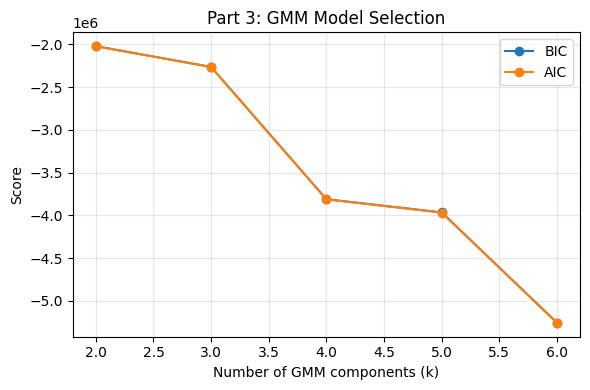

Selected k by minimum BIC: 6


,k,bic,aic
0,2,-2.021588e+06,-2.022461e+06
1,3,-2.264151e+06,-2.265465e+06
2,4,-3.810852e+06,-3.812608e+06
3,5,-3.964422e+06,-3.966619e+06
4,6,-5.253775e+06,-5.256414e+06


,cluster_id,avg_user_sentiment,sentiment_volatility,escalation_event_rate,avg_utterance_length,first_turn_frustration,recovery_rate,dropout_flag,question_ratio,n_turns
0,0,0.000000,0.000000,0.000000,17.525350,0.114815,0.000000,0.000000,0.205508,3.976105
1,1,0.004728,0.035637,0.659882,23.801694,0.306144,0.000000,0.670592,0.225006,2.545960
2,2,0.023743,0.205290,0.044137,20.195403,0.139663,1.100389,0.512729,0.174430,3.543813
3,3,0.032062,0.000000,0.000000,17.723291,0.129881,0.000000,1.000000,0.000000,1.142121
4,4,0.178120,0.276382,0.000000,18.070143,0.120622,0.000000,0.530490,0.238799,3.039097
5,5,0.007850,0.000000,0.000000,19.996029,0.116115,0.000000,1.000000,0.912217,1.219945


In [51]:
# GMM model selection by BIC
X = persona_features[persona_feature_cols].fillna(0.0).to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

bic_rows = []
gmm_candidates = {}
for k in range(2, 7):
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    gmm.fit(X_scaled)
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)
    bic_rows.append({"k": k, "bic": bic, "aic": aic})
    gmm_candidates[k] = gmm

bic_df = pd.DataFrame(bic_rows).sort_values("k")
best_k = int(bic_df.loc[bic_df["bic"].idxmin(), "k"])
best_gmm = gmm_candidates[best_k]

cluster_id = best_gmm.predict(X_scaled)
cluster_probs = best_gmm.predict_proba(X_scaled)
max_prob = cluster_probs.max(axis=1)

persona_features["cluster_id"] = cluster_id
persona_features["cluster_confidence"] = max_prob

# Derive human-readable persona names from cluster statistics
cluster_profile = persona_features.groupby("cluster_id", as_index=False)[persona_feature_cols + ["n_turns"]].mean()
cluster_profile = cluster_profile.sort_values("cluster_id")

cluster_name_map = {}
for _, row in cluster_profile.iterrows():
    cid = int(row["cluster_id"])
    if row["dropout_flag"] > 0.45 and row["avg_utterance_length"] < 12:
        cluster_name_map[cid] = "silent_dropout"
    elif row["escalation_event_rate"] > 0.20 or row["first_turn_frustration"] > 0.55:
        cluster_name_map[cid] = "escalation_prone"
    elif row["sentiment_volatility"] > 0.45 and row["avg_utterance_length"] < 20:
        cluster_name_map[cid] = "impatient"
    else:
        cluster_name_map[cid] = "cooperative"

persona_features["persona_cluster"] = persona_features["cluster_id"].map(cluster_name_map)

# Save model-selection plot
plt.figure(figsize=(6, 4))
plt.plot(bic_df["k"], bic_df["bic"], marker="o", label="BIC")
plt.plot(bic_df["k"], bic_df["aic"], marker="o", label="AIC")
plt.xlabel("Number of GMM components (k)")
plt.ylabel("Score")
plt.title("Part 3: GMM Model Selection")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PART3_DIR / "part3_gmm_bic_aic.png", dpi=140)
plt.show()

print(f"Selected k by minimum BIC: {best_k}")
display(bic_df)
display(cluster_profile)

In [52]:
# Export Part 3 artifacts
persona_features_path = PART3_DIR / "part3_persona_features.csv"
bic_path = PART3_DIR / "part3_gmm_bic_aic.csv"
cluster_profile_path = PART3_DIR / "part3_cluster_profiles.csv"
cluster_map_path = PART3_DIR / "part3_cluster_name_map.json"
summary_path = PART3_DIR / "part3_summary_metrics.csv"
report_path = PART3_DIR / "part3_persona_report.md"

persona_features.to_csv(persona_features_path, index=False)
bic_df.to_csv(bic_path, index=False)
cluster_profile.to_csv(cluster_profile_path, index=False)
with cluster_map_path.open("w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in cluster_name_map.items()}, f, indent=2)

summary_metrics = pd.DataFrame([
    {"metric": "source_rows_customer_turns", "value": int(len(user_df))},
    {"metric": "conversation_proxies", "value": int(len(persona_features))},
    {"metric": "best_k_bic", "value": int(best_k)},
    {"metric": "mean_cluster_confidence", "value": float(persona_features["cluster_confidence"].mean())},
])
summary_metrics.to_csv(summary_path, index=False)

persona_dist = persona_features["persona_cluster"].value_counts(normalize=True).mul(100).round(2)

report_lines = [
    "# Part 3 Persona Clustering Report",
    "",
    f"- Source file: {source_twitter_path}",
    f"- Customer turns used: {len(user_df):,}",
    f"- Conversation proxies: {len(persona_features):,}",
    f"- Selected GMM components (BIC): {best_k}",
    f"- Mean cluster confidence: {persona_features['cluster_confidence'].mean():.3f}",
    "",
    "## Persona Distribution (%)",
]
for name, pct in persona_dist.items():
    report_lines.append(f"- {name}: {pct:.2f}")

report_lines.extend([
    "",
    "## Exported Files",
    "- part3_persona_features.csv",
    "- part3_gmm_bic_aic.csv",
    "- part3_cluster_profiles.csv",
    "- part3_cluster_name_map.json",
    "- part3_summary_metrics.csv",
    "- part3_gmm_bic_aic.png",
])

report_path.write_text("\n".join(report_lines), encoding="utf-8")

display(summary_metrics)
print("Saved:", persona_features_path)
print("Saved:", bic_path)
print("Saved:", cluster_profile_path)
print("Saved:", cluster_map_path)
print("Saved:", summary_path)
print("Saved:", report_path)
print("Saved:", PART3_DIR / "part3_gmm_bic_aic.png")

,metric,value
0,source_rows_customer_turns,219701.000000
1,conversation_proxies,134419.000000
2,best_k_bic,6.000000
3,mean_cluster_confidence,0.999905


Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part3_persona_clustering\part3_persona_features.csv
Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part3_persona_clustering\part3_gmm_bic_aic.csv
Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part3_persona_clustering\part3_cluster_profiles.csv
Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part3_persona_clustering\part3_cluster_name_map.json
Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part3_persona_clustering\part3_summary_metrics.csv
Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Servic

## Part 4: Dual-Index RAG Build (Implemented)

This part builds retrieval infrastructure for simulation:

- Turn-level index: retrieve similar user turns for next-turn generation
- Conversation-level index: retrieve similar trajectories/persona contexts for episode initialization

Implementation notes:
- Uses TF-IDF + cosine NearestNeighbors as a robust local baseline
- Exports models and metadata for reuse in later simulation steps
- Includes helper retrieval functions for both indices

Output folder:
- Simulation/artifacts/part4_rag_indices

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import joblib

PART4_DIR = ROOT / "Simulation" / "artifacts" / "part4_rag_indices"
PART4_DIR.mkdir(parents=True, exist_ok=True)

# Keep index sizes practical while preserving signal diversity.
MAX_TURN_INDEX_ROWS = 150000
MAX_CONV_INDEX_ROWS = 80000

print("Part 4 output dir:", PART4_DIR)

Part 4 output dir: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part4_rag_indices


In [54]:
# ---------- Build Turn-Level Index ----------
if "user_df" not in globals() or "persona_features" not in globals():
    raise RuntimeError("Part 4 requires Part 3 outputs (user_df and persona_features). Run Part 3 first.")

turn_meta = user_df[["conversation_proxy_id", "author_id", "created_at_dt", "text", "sentiment_score", "frustration_proxy"]].copy()
turn_meta = turn_meta.rename(columns={"text": "utterance_text"})

persona_lookup = persona_features[["conversation_proxy_id", "persona_cluster", "cluster_id", "cluster_confidence"]].copy()
turn_meta = turn_meta.merge(persona_lookup, on="conversation_proxy_id", how="left")
turn_meta["persona_cluster"] = turn_meta["persona_cluster"].fillna("unknown")

# Balanced sampling across personas for index quality.
def sample_turns_balanced(df, n_total=MAX_TURN_INDEX_ROWS, random_state=42):
    if len(df) <= n_total:
        return df.copy()

    groups = []
    personas = sorted(df["persona_cluster"].dropna().unique().tolist())
    n_per = max(1, n_total // max(len(personas), 1))

    for p_name in personas:
        sub = df[df["persona_cluster"] == p_name]
        take = min(n_per, len(sub))
        groups.append(sub.sample(n=take, random_state=random_state))

    sampled = pd.concat(groups, ignore_index=False)
    if len(sampled) < n_total:
        remain = df.loc[~df.index.isin(sampled.index)]
        top_up = remain.sample(n=min(n_total - len(sampled), len(remain)), random_state=random_state)
        sampled = pd.concat([sampled, top_up], ignore_index=False)

    return sampled.sample(frac=1.0, random_state=random_state).head(n_total).reset_index(drop=True)

turn_meta_idx = sample_turns_balanced(turn_meta, n_total=MAX_TURN_INDEX_ROWS)

turn_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    max_features=40000,
    ngram_range=(1, 2),
    min_df=2,
)
X_turn = turn_vectorizer.fit_transform(turn_meta_idx["utterance_text"].fillna(""))

turn_nn = NearestNeighbors(n_neighbors=25, metric="cosine", algorithm="brute")
turn_nn.fit(X_turn)

turn_meta_path = PART4_DIR / "part4_turn_index_metadata.csv"
turn_model_path = PART4_DIR / "part4_turn_nn.joblib"
turn_vectorizer_path = PART4_DIR / "part4_turn_vectorizer.joblib"

turn_meta_idx.to_csv(turn_meta_path, index=False)
joblib.dump(turn_nn, turn_model_path)
joblib.dump(turn_vectorizer, turn_vectorizer_path)

print(f"Turn index rows: {len(turn_meta_idx):,}")
print(f"Turn index vocab size: {len(turn_vectorizer.vocabulary_):,}")
print("Saved:", turn_meta_path)
print("Saved:", turn_model_path)
print("Saved:", turn_vectorizer_path)

Turn index rows: 150,000
Turn index vocab size: 40,000
Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part4_rag_indices\part4_turn_index_metadata.csv
Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part4_rag_indices\part4_turn_nn.joblib
Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part4_rag_indices\part4_turn_vectorizer.joblib


In [55]:
# ---------- Build Conversation-Level Index ----------
conv_text = (
    user_df.groupby("conversation_proxy_id", as_index=False)
    .agg(
        convo_text=("text", lambda s: " ".join(s.head(6).astype(str).tolist())),
        conv_turns=("text", "size"),
        avg_sent=("sentiment_score", "mean"),
        avg_frustration=("frustration_proxy", "mean"),
    )
)

conv_idx_df = persona_features.merge(conv_text, on="conversation_proxy_id", how="left")
conv_idx_df["convo_text"] = conv_idx_df["convo_text"].fillna("")

# Keep one canonical turns column after merge.
if "n_turns" not in conv_idx_df.columns:
    if "n_turns_x" in conv_idx_df.columns:
        conv_idx_df["n_turns"] = conv_idx_df["n_turns_x"]
    elif "conv_turns" in conv_idx_df.columns:
        conv_idx_df["n_turns"] = conv_idx_df["conv_turns"]
    else:
        conv_idx_df["n_turns"] = 0

# Mixed summary string keeps retrieval interpretable and portable.
conv_idx_df["summary_text"] = (
    "persona=" + conv_idx_df["persona_cluster"].astype(str)
    + " turns=" + conv_idx_df["n_turns"].fillna(0).round(0).astype(int).astype(str)
    + " escalation_rate=" + conv_idx_df["escalation_event_rate"].fillna(0).round(3).astype(str)
    + " question_ratio=" + conv_idx_df["question_ratio"].fillna(0).round(3).astype(str)
    + " text=" + conv_idx_df["convo_text"].astype(str)
)

if len(conv_idx_df) > MAX_CONV_INDEX_ROWS:
    conv_idx_df = conv_idx_df.sample(n=MAX_CONV_INDEX_ROWS, random_state=42).reset_index(drop=True)

conv_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
)
X_conv = conv_vectorizer.fit_transform(conv_idx_df["summary_text"])

conv_nn = NearestNeighbors(n_neighbors=25, metric="cosine", algorithm="brute")
conv_nn.fit(X_conv)

conv_meta_path = PART4_DIR / "part4_conversation_index_metadata.csv"
conv_model_path = PART4_DIR / "part4_conversation_nn.joblib"
conv_vectorizer_path = PART4_DIR / "part4_conversation_vectorizer.joblib"

conv_idx_df.to_csv(conv_meta_path, index=False)
joblib.dump(conv_nn, conv_model_path)
joblib.dump(conv_vectorizer, conv_vectorizer_path)

print(f"Conversation index rows: {len(conv_idx_df):,}")
print(f"Conversation index vocab size: {len(conv_vectorizer.vocabulary_):,}")
print("Saved:", conv_meta_path)
print("Saved:", conv_model_path)
print("Saved:", conv_vectorizer_path)

Conversation index rows: 80,000
Conversation index vocab size: 50,000
Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part4_rag_indices\part4_conversation_index_metadata.csv
Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part4_rag_indices\part4_conversation_nn.joblib
Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part4_rag_indices\part4_conversation_vectorizer.joblib


In [56]:
# ---------- Retrieval Helper Functions ----------
def retrieve_similar_turns(query_text, persona_filter=None, k=5):
    q = turn_vectorizer.transform([clean_text(query_text)])
    distances, indices = turn_nn.kneighbors(q, n_neighbors=min(50, len(turn_meta_idx)))

    cand = turn_meta_idx.iloc[indices[0]].copy()
    cand["distance"] = distances[0]

    if persona_filter is not None:
        cand = cand[cand["persona_cluster"].astype(str).str.lower() == str(persona_filter).lower()]

    return cand.sort_values("distance").head(k).reset_index(drop=True)


def retrieve_similar_conversations(query_text, persona_hint=None, k=5):
    q = conv_vectorizer.transform([clean_text(query_text)])
    distances, indices = conv_nn.kneighbors(q, n_neighbors=min(50, len(conv_idx_df)))

    cand = conv_idx_df.iloc[indices[0]].copy()
    cand["distance"] = distances[0]

    if persona_hint is not None:
        cand = cand[cand["persona_cluster"].astype(str).str.lower() == str(persona_hint).lower()]

    cols = [
        "conversation_proxy_id", "persona_cluster", "n_turns", "escalation_event_rate",
        "question_ratio", "cluster_confidence", "distance", "convo_text"
    ]
    cols = [c for c in cols if c in cand.columns]
    return cand[cols].sort_values("distance").head(k).reset_index(drop=True)


# Quick sanity checks
turn_demo = retrieve_similar_turns(
    query_text="my order still has not arrived and nobody is helping", persona_filter="escalation_prone", k=5
)
conv_demo = retrieve_similar_conversations(
    query_text="customer angry wants manager and quick resolution", persona_hint="escalation_prone", k=5
)

display(turn_demo[["utterance_text", "persona_cluster", "distance"]])
display(conv_demo)

,utterance_text,persona_cluster,distance
0,@SouthwestAir in several times but nobody is h...,escalation_prone,0.754573
1,@Delta Yes but my printed ticket won't even gi...,escalation_prone,0.803180


,conversation_proxy_id,persona_cluster,n_turns,escalation_event_rate,question_ratio,cluster_confidence,distance,convo_text
0,179971_2,escalation_prone,2,1.0,0.0,1.0,0.754599,@SpotifyCares im lookidng for a a&amp;r are ma...
1,175994_1,escalation_prone,1,1.0,0.0,1.0,0.786346,Wal Mart sent me on a week long training to be...
2,119518_2,escalation_prone,1,1.0,0.0,1.0,0.826387,"@CoxHelp The internet has gone out yet again ,..."
3,186925_1,escalation_prone,2,0.5,0.0,1.0,0.839982,"@BofA_Help This was on the main help line, aft..."
4,201711_1,escalation_prone,2,0.5,0.5,1.0,0.846952,"@AskPlayStation please help me, after the upda..."


In [57]:
# ---------- Part 4 Summary Export ----------
part4_summary = pd.DataFrame([
    {"metric": "turn_index_rows", "value": int(len(turn_meta_idx))},
    {"metric": "turn_index_vocab", "value": int(len(turn_vectorizer.vocabulary_))},
    {"metric": "conversation_index_rows", "value": int(len(conv_idx_df))},
    {"metric": "conversation_index_vocab", "value": int(len(conv_vectorizer.vocabulary_))},
])

part4_summary_path = PART4_DIR / "part4_summary_metrics.csv"
part4_summary.to_csv(part4_summary_path, index=False)

part4_report_path = PART4_DIR / "part4_rag_index_report.md"
part4_report_lines = [
    "# Part 4 RAG Index Report",
    "",
    "## Built Indices",
    f"- Turn-level rows: {len(turn_meta_idx):,}",
    f"- Turn-level vocabulary: {len(turn_vectorizer.vocabulary_):,}",
    f"- Conversation-level rows: {len(conv_idx_df):,}",
    f"- Conversation-level vocabulary: {len(conv_vectorizer.vocabulary_):,}",
    "",
    "## Saved Artifacts",
    "- part4_turn_index_metadata.csv",
    "- part4_turn_nn.joblib",
    "- part4_turn_vectorizer.joblib",
    "- part4_conversation_index_metadata.csv",
    "- part4_conversation_nn.joblib",
    "- part4_conversation_vectorizer.joblib",
    "- part4_summary_metrics.csv",
]
part4_report_path.write_text("\n".join(part4_report_lines), encoding="utf-8")

display(part4_summary)
print("Saved:", part4_summary_path)
print("Saved:", part4_report_path)

,metric,value
0,turn_index_rows,150000
1,turn_index_vocab,40000
2,conversation_index_rows,80000
3,conversation_index_vocab,50000


Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part4_rag_indices\part4_summary_metrics.csv
Saved: B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\Simulation\artifacts\part4_rag_indices\part4_rag_index_report.md
